#### 로지스틱 회귀로 와인 분류하기

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 데이터 불러오기
wine = pd.read_csv("../Data/wine.csv")
wine.head() 

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [3]:
# 크기
wine.shape

(6497, 4)

In [4]:
# NaN check
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [5]:
# class의 종류
wine['class'].value_counts()

class
1.0    4898
0.0    1599
Name: count, dtype: int64

> 0 : Red Wine, 1: White Wine

In [6]:
# 기본 통계량
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [8]:
# Feature와 Target을 Numpy로 생성하기
data = wine.iloc[:,:3].to_numpy()
target = wine.iloc[:,-1].to_numpy()

In [9]:
data[:5]

array([[9.4 , 1.9 , 3.51],
       [9.8 , 2.6 , 3.2 ],
       [9.8 , 2.3 , 3.26],
       [9.8 , 1.9 , 3.16],
       [9.4 , 1.9 , 3.51]])

In [10]:
target[:5]

array([0., 0., 0., 0., 0.])

#### Train과 Test

In [11]:
# test의 크기는 20%로 
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = \
                            train_test_split(
                                data,
                                target,
                                test_size=0.2,
                                random_state=42
                            )

In [12]:
print("Train :", train_input.shape)
print("Train :", test_input.shape)

Train : (5197, 3)
Train : (1300, 3)


In [14]:
1300/(5197+1300)

0.20009235031553024

#### 로지스틱 회귀이므로 표준화 하기

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

#### 로지스틱 회귀 모델

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print("Train :", lr.score(train_scaled, train_target))
print("Test  :", lr.score(test_scaled, test_target))

Train : 0.7808350971714451
Test  : 0.7776923076923077


In [21]:
# 가중치와 편차 구하기
print(lr.coef_, lr.intercept_)

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


class = 0.51268071 * alcohol + 1.67335441 * sugar + -0.68775646 * ph + 1.81773456

In [22]:
train_scaled

array([[ 0.01376574,  0.4646116 , -0.16888369],
       [ 1.60871671, -0.70299854,  0.26967864],
       [ 1.10504798, -0.70299854,  1.20945505],
       ...,
       [-0.82568214,  0.0267578 ,  0.14437512],
       [-0.82568214,  0.52716215, -0.23153545],
       [-0.82568214, -0.57789745,  1.83597265]])

In [23]:
train_target

array([1., 0., 0., ..., 1., 1., 0.])

In [27]:
(0.51268071 * 0.01376574) + (1.67335441 * 0.4646116) + (-0.68775646 * -0.16888369) + 1.81773456

2.718402707940169

In [26]:
0.51268071 * 1.60871671 + 1.67335441 * -0.70299854 + -0.68775646 * 0.26967864 + 1.81773456

1.2806536511550886

In [31]:
decisions = lr.decision_function(train_scaled[:2])

In [33]:
# Sigmoid에 적용후 판단 

from scipy.special import expit
expit(decisions)

array([0.93810385, 0.78256102])

---
#### 결정트리(Decision Tree)
: 선형회귀나 KNN처럼 전처리 과정이 필요없다.

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_input, train_target)
print("Train :", dt.score(train_input, train_target))
print("Test  :", dt.score(test_input, test_target))

Train : 0.996921300750433
Test  : 0.8584615384615385


#### 시각화

In [36]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

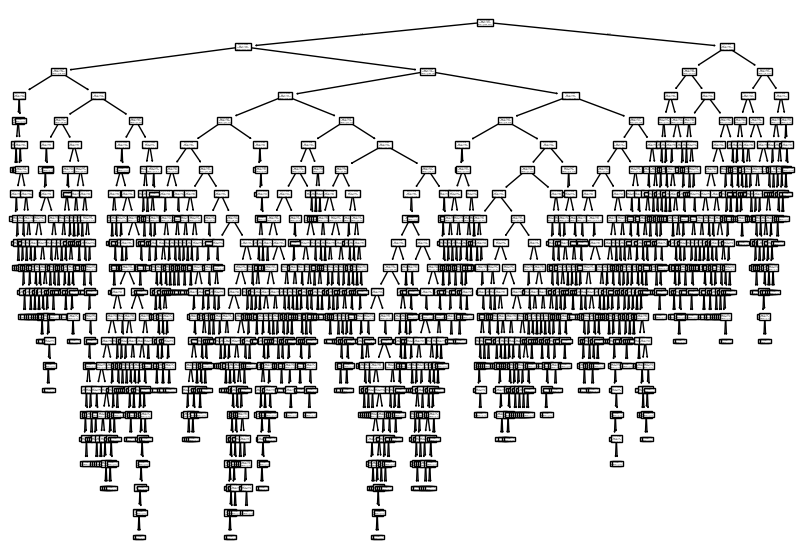

In [37]:
plt.figure(figsize=(10,7))
plot_tree(dt)
plt.show()

맨위의 단계를 root node라고 하고 맨 마지막 단계는 leaf node라고 한다.   
시간이 너무 많이 걸리고 단계가 너무 복잡하다.   

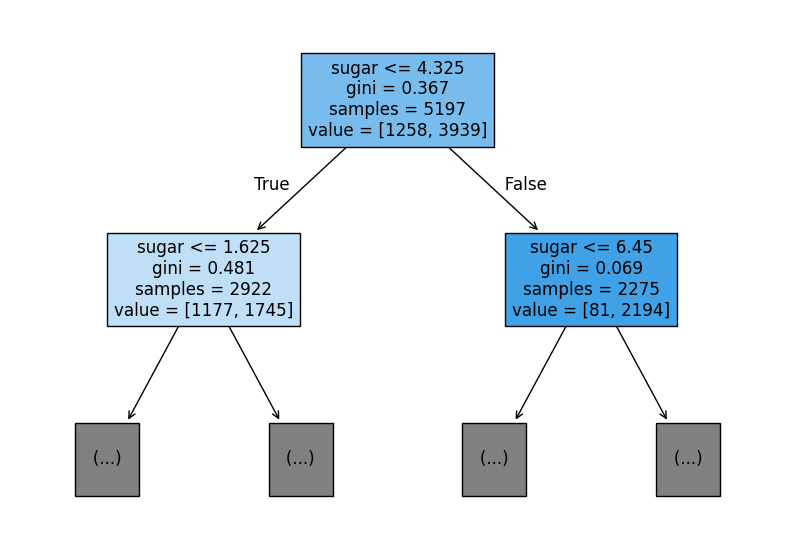

In [38]:
# decision tree의 단계(depth)를 단순화 하자
plt.figure(figsize=(10, 7))
plot_tree(
    dt,
    max_depth=1,
    filled=True,
    feature_names=['alcohol', 'sugar','pH']
)
plt.show()

- 양성(True, 1)일수록 파란색으로 표시된다.
- 루트노드에서 sugar >= 4.325 이면 왼쪽으로 이동하고 아니면 오른쪽으로 이동한다. 
- 총 갯수가 5197개인데 True인 노드는 2922개이고 False노드는 2275개 이다.  
- 지니 불순도(Gini impurity)가 0이 나올때롤 순수노드 라고 하다.  
- 지니 불순도 = 1 - ((음성클래스 비율^2) + (양성클래스 비율^2))
- leaf node가 순수노드 인건 좋으나 이때 과대적합이 발생한다.  
- 따라서 적절하 max_depth를 찾는 것이 중요하다.
- 불순도에 따라서 tree가 나뉘어 진다. 

In [39]:
1 - ((1258/5197)**2 + (3939/5197)**2)

0.3669367279393918

#### 가지치기(Tree Pruning)
- max_depth의 parameter값을 조절한다.
- Decision Tree의 과대적합을 막는다. 
- 선형회귀식처럼 L1규제, L2규제를 사용할 수 없다. 

In [40]:
dt = DecisionTreeClassifier(random_state=42, max_depth=3)
dt.fit(train_input, train_target)
print("Train :", dt.score(train_input, train_target))
print("Test  :", dt.score(test_input, test_target))

Train : 0.8454877814123533
Test  : 0.8415384615384616


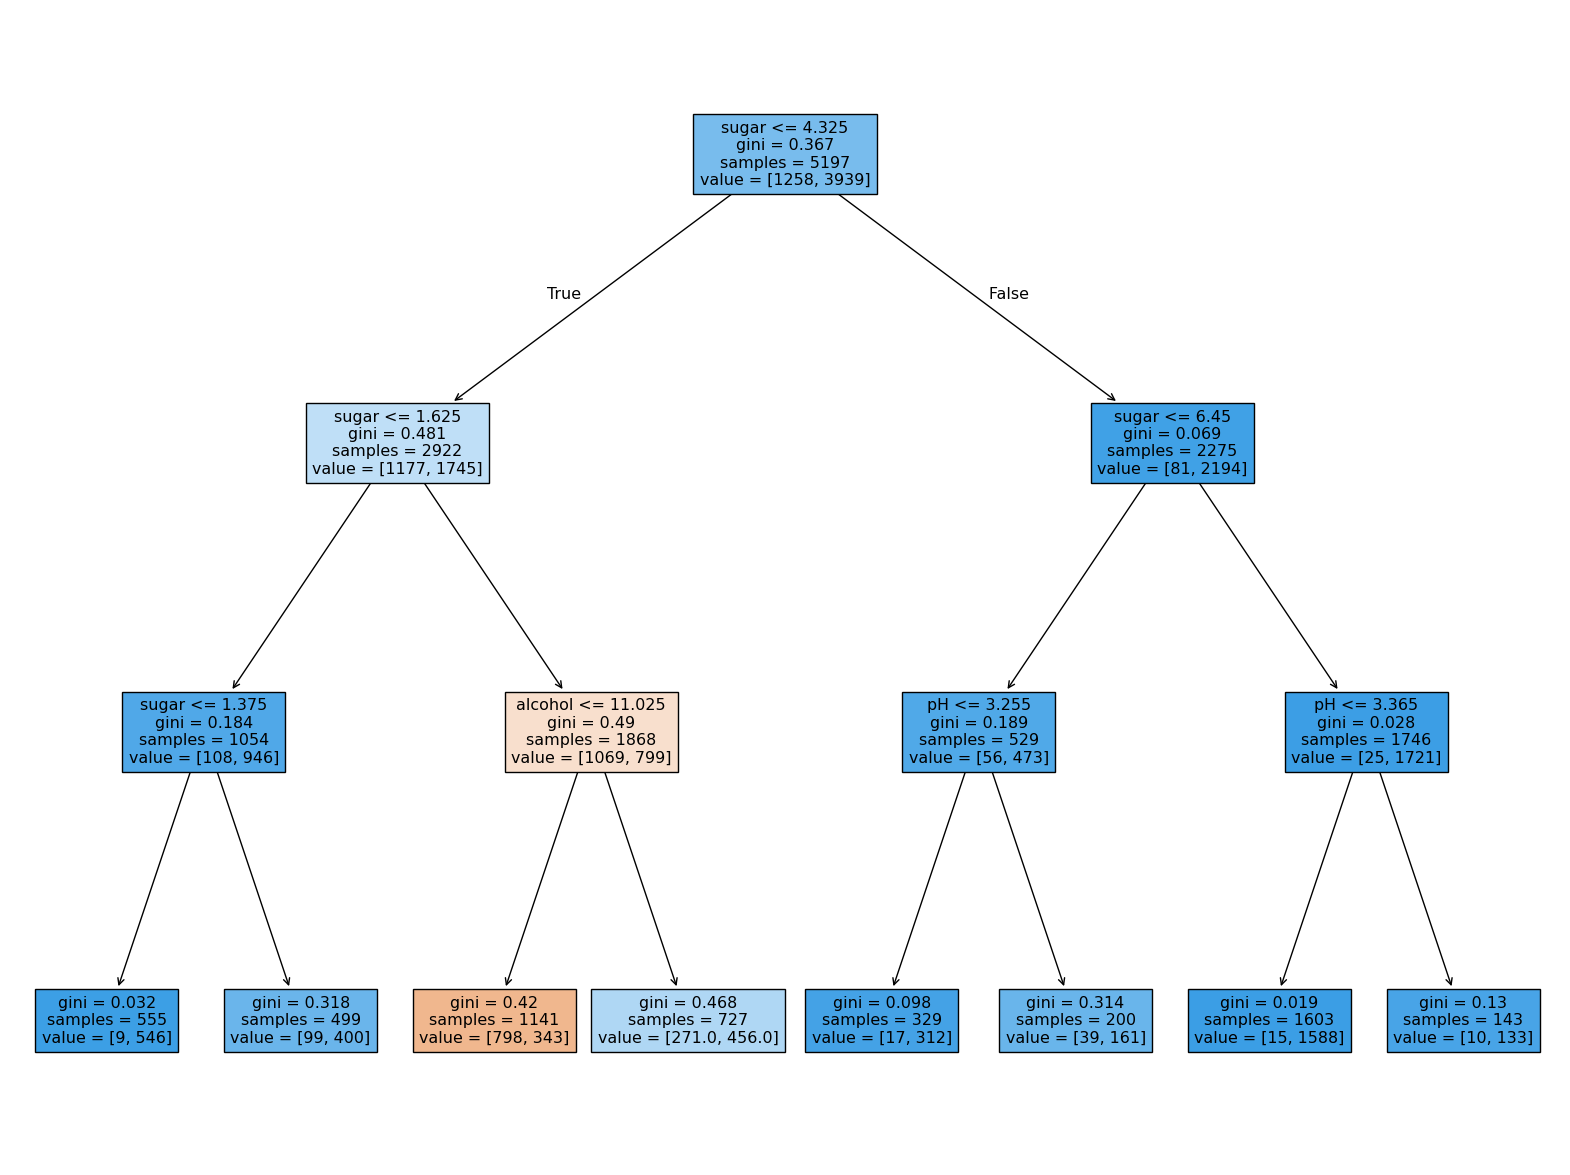

In [41]:
# 시각화 
plt.figure(figsize=(20, 15))
plot_tree(
    dt,
    filled=True,
    feature_names=['alcohol', 'sugar','pH']
)
plt.show()

In [42]:
# 특성 중요도
dt.feature_importances_

array([0.12345626, 0.86862934, 0.0079144 ])

> alcohol, sugar, pH의 순으로 특성중요도가 출력되며   
이중 sugar가 제일 중요한 요소로 작동 된다는 것을 알 수 있다. 

---
#### 최적화 시키기

In [43]:
dt = DecisionTreeClassifier(random_state=42, min_impurity_decrease=0.0005) # 0.05% 
dt.fit(train_input, train_target)
print("Train :", dt.score(train_input, train_target))
print("Test  :", dt.score(test_input, test_target))

Train : 0.8874350586877044
Test  : 0.8615384615384616


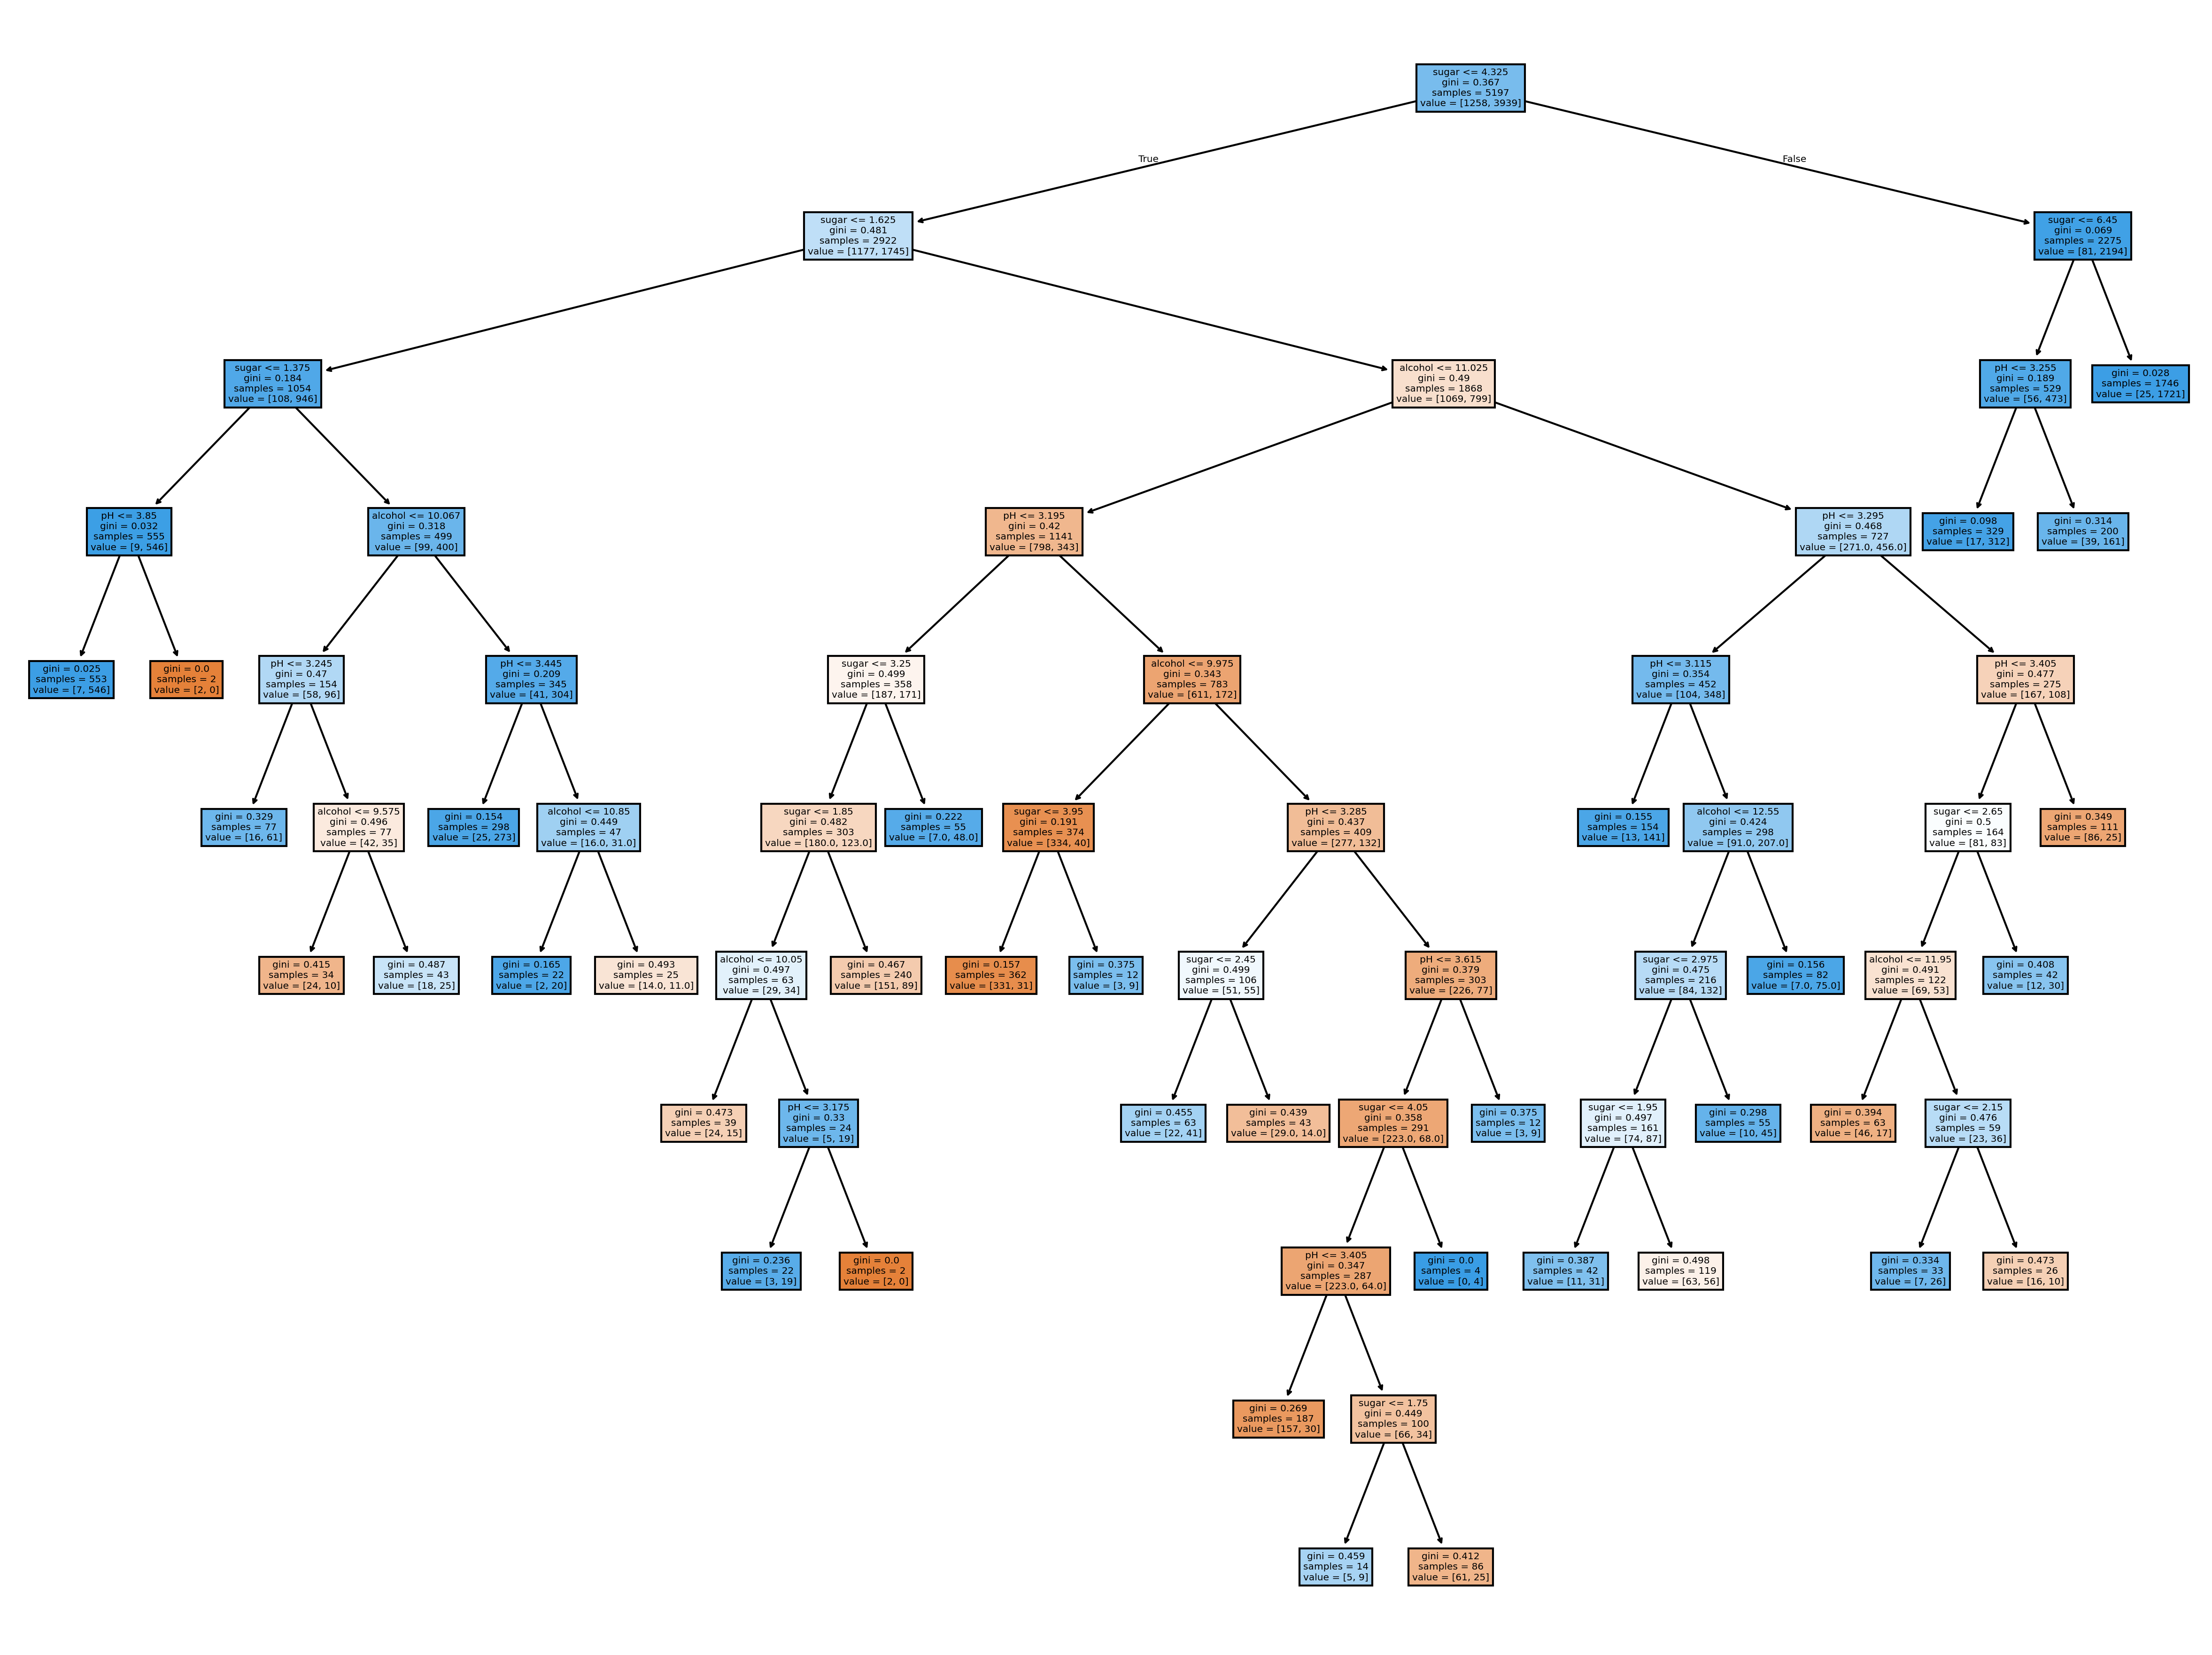

In [46]:
# 시각화 
plt.figure(figsize=(20, 15), dpi=300)
plot_tree(
    dt,
    filled=True,
    feature_names=['alcohol', 'sugar','pH']
)
plt.savefig("../Data/wine.jpg")
plt.show()